### Try to convert h5ad file to seurat/signac obj

In [1]:

library(Matrix)
library(GenomicRanges)
library(EnsDb.Hsapiens.v86)
library(Seurat)
library(Signac)

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:Matrix’:

    expand, unname


The

In [3]:
if (!requireNamespace("BiocManager", quietly=TRUE)) {
    install.packages("BiocManager")
}
BiocManager::install("zellkonverter")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.21 (BiocManager 1.30.27), R 4.5.1 (2025-06-13)

Installing package(s) 'zellkonverter'

also installing the dependencies 'dir.expiry', 'basilisk.utils', 'basilisk'


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Old packages: 'base64enc', 'BH', 'blob', 'broom', 'bslib', 'carData',
  'checkmate', 'cluster', 'cpp11', 'data.table', 'DBI', 'dbplyr', 'digest',
  'doBy', 'dplyr', 'e1071', 'fansi', 'fastmatch', 'fitdistrplus', 'foreign',
  'fs', 'futile.logger', 'future', 'future.apply', 'gert', 'ggplot2',
  'ggrepel', 'ggsci', 'ggseqlogo', 'globals', 'gplots', 'highr', 'Hmisc',
  'htmltools', 'httr', 'httr2', 'igraph', 'irlba', 'isoband', 'knitr', 'later',
  'lattice', 'leidenbase', 'lifecycle', 'listenv', 'mathjaxr', 'openssl',
  'parallelly',

In [2]:
library(zellkonverter)

Registered S3 method overwritten by 'zellkonverter':
  method                                             from      
  py_to_r.pandas.core.arrays.categorical.Categorical reticulate



In [ ]:


rna_assay <- "/nfs/data3/mopitas/mapra/cell_atlas_data/multiome_h5ad/Global_raw.h5ad"
peak_assay <- "/nfs/data3/mopitas/mapra/cell_atlas_data/multiome_h5ad/Adult_Peaks.h5ad"

stopifnot(file.exists(rna_assay))
stopifnot(file.exists(peak_assay))

# You do not need a 10x feature_bc_matrix.h5 here.
# Read the two h5ad files directly and build the same structure that Read10X_h5() would return.
rna_sce <- zellkonverter::readH5AD(rna_assay)
peak_sce <- zellkonverter::readH5AD(peak_assay)


+ /nfs/home/students/m.back/.cache/R/basilisk/1.20.0/0/bin/conda create --yes --prefix /nfs/home/students/m.back/.cache/R/basilisk/1.20.0/zellkonverter/1.18.0/zellkonverterAnnDataEnv-0.11.4 'python=3.13.2' --quiet -c conda-forge --override-channels

+ /nfs/home/students/m.back/.cache/R/basilisk/1.20.0/0/bin/conda install --yes --prefix /nfs/home/students/m.back/.cache/R/basilisk/1.20.0/zellkonverter/1.18.0/zellkonverterAnnDataEnv-0.11.4 'python=3.13.2' -c conda-forge --override-channels

+ /nfs/home/students/m.back/.cache/R/basilisk/1.20.0/0/bin/conda install --yes --prefix /nfs/home/students/m.back/.cache/R/basilisk/1.20.0/zellkonverter/1.18.0/zellkonverterAnnDataEnv-0.11.4 -c conda-forge 'python=3.13.2' 'anndata=0.11.4' 'h5py=3.13.0' 'hdf5=1.14.3' 'natsort=8.4.0' 'numpy=2.2.4' 'packaging=24.2' 'pandas=2.2.3' 'python=3.13.2' 'scipy=1.15.2' --override-channels

Warning message:
"The names of these selected var columns have been modified to match R
conventions: 'gene_name-new' -> 'gene_

In [8]:

get_counts_matrix <- function(sce) {
  assay_priority <- c("counts", "X", "data")
  assay_name <- assay_priority[assay_priority %in% SummarizedExperiment::assayNames(sce)][1]
  if (is.na(assay_name)) {
    stop(
      "No usable assay found. Available assays: ",
      paste(SummarizedExperiment::assayNames(sce), collapse = ", ")
    )
  }
  mat <- SummarizedExperiment::assay(sce, assay_name)
  if (!inherits(mat, "dgCMatrix")) {
    mat <- as(mat, "dgCMatrix")
  }
  mat
}

make_peak_names <- function(sce) {
  rd <- as.data.frame(SummarizedExperiment::rowData(sce))
  if (!is.null(rownames(sce)) && all(nzchar(rownames(sce)))) {
    return(rownames(sce))
  }

  required_cols <- c("seqnames", "start", "end")
  if (all(required_cols %in% colnames(rd))) {
    return(paste0(rd$seqnames, ":", rd$start, "-", rd$end))
  }

  stop(
    "Could not derive peak names from peak h5ad. ",
    "Need rownames or rowData columns seqnames/start/end."
  )
}


In [9]:

rna_counts <- get_counts_matrix(rna_sce)
peak_counts <- get_counts_matrix(peak_sce)

common_cells <- intersect(colnames(rna_counts), colnames(peak_counts))
if (length(common_cells) == 0) {
  stop("RNA and peak matrices have no overlapping cell barcodes.")
}

In [11]:


rna_counts <- rna_counts[, common_cells, drop = FALSE]
peak_counts <- peak_counts[, common_cells, drop = FALSE]

peak_names <- make_peak_names(peak_sce)
rownames(peak_counts) <- peak_names

In [12]:

counts <- list(
  "Gene Expression" = rna_counts,
  "Peaks" = peak_counts
)

In [14]:

# Save to disk
out_dir <- "/nfs/data3/mopitas/mapra/cell_atlas_data/rds_data"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

rna_sce_path <- file.path(out_dir, "rna_sce.rds")
peak_sce_path <- file.path(out_dir, "peak_sce.rds")
counts_path <- file.path(out_dir, "counts.rds")

saveRDS(rna_sce, rna_sce_path)
saveRDS(peak_sce, peak_sce_path)
saveRDS(counts, counts_path)

cat("Saved:\n")
cat("  -", rna_sce_path, "\n")
cat("  -", peak_sce_path, "\n")
cat("  -", counts_path, "\n")


Saved:
  - /nfs/data3/mopitas/mapra/cell_atlas_data/rds_data/rna_sce.rds 
  - /nfs/data3/mopitas/mapra/cell_atlas_data/rds_data/peak_sce.rds 
  - /nfs/data3/mopitas/mapra/cell_atlas_data/rds_data/counts.rds 


In [2]:
# read files
out_dir <- "/nfs/data3/mopitas/mapra/cell_atlas_data/rds_data"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

rna_sce_path <- file.path(out_dir, "rna_sce.rds")
peak_sce_path <- file.path(out_dir, "peak_sce.rds")
counts_path <- file.path(out_dir, "counts.rds")

print("paths set")
rna_sce <- readRDS(rna_sce_path)
print("read rna_sce")
peak_sce <- readRDS(peak_sce_path)
print("read peak_sce")
counts <- readRDS(counts_path)
print("read counts")

[1] "paths set"


In [3]:
counts <- readRDS(counts_path)
print("read counts")

[1] "read counts"


In [8]:
str(rna_sce, max.level = 3)

Formal class 'SingleCellExperiment' [package "SingleCellExperiment"] with 9 slots
  ..@ int_elementMetadata:Formal class 'DFrame' [package "S4Vectors"] with 6 slots
  ..@ int_colData        :Formal class 'DFrame' [package "S4Vectors"] with 6 slots
  ..@ int_metadata       :List of 1
  .. ..$ version:Classes 'package_version', 'numeric_version'  hidden list of 1
  ..@ rowRanges          :Formal class 'CompressedGRangesList' [package "GenomicRanges"] with 5 slots
  ..@ colData            :Formal class 'DFrame' [package "S4Vectors"] with 6 slots
  ..@ assays             :Formal class 'SimpleAssays' [package "SummarizedExperiment"] with 1 slot
  ..@ NAMES              : NULL
  ..@ elementMetadata    :Formal class 'DFrame' [package "S4Vectors"] with 6 slots
  ..@ metadata           :List of 18
  .. ..$ age_colors               : chr [1:9(1d)] "#1f77b4" "#ff7f0e" "#279e68" "#d62728" ...
  .. ..$ cell_or_nuclei_colors    : chr [1:2(1d)] "#1f77b4" "#ff7f0e"
  .. ..$ cell_state_colors        : 

### read var and obs metadata

In [5]:
rna_obs <- read.csv(
  "/nfs/data3/mopitas/mapra/cell_atlas_data/multiome_h5ad/Global_raw_obs.csv",
  row.names = 1,
  check.names = FALSE
 )
rna_var <- read.csv(
  "/nfs/data3/mopitas/mapra/cell_atlas_data/multiome_h5ad/Global_raw_var.csv",
  row.names = 1,
  check.names = FALSE
 )
peak_obs <- read.csv(
  "/nfs/data3/mopitas/mapra/cell_atlas_data/multiome_h5ad/Adult_Peaks_obs.csv",
  row.names = 1,
  check.names = FALSE
 )

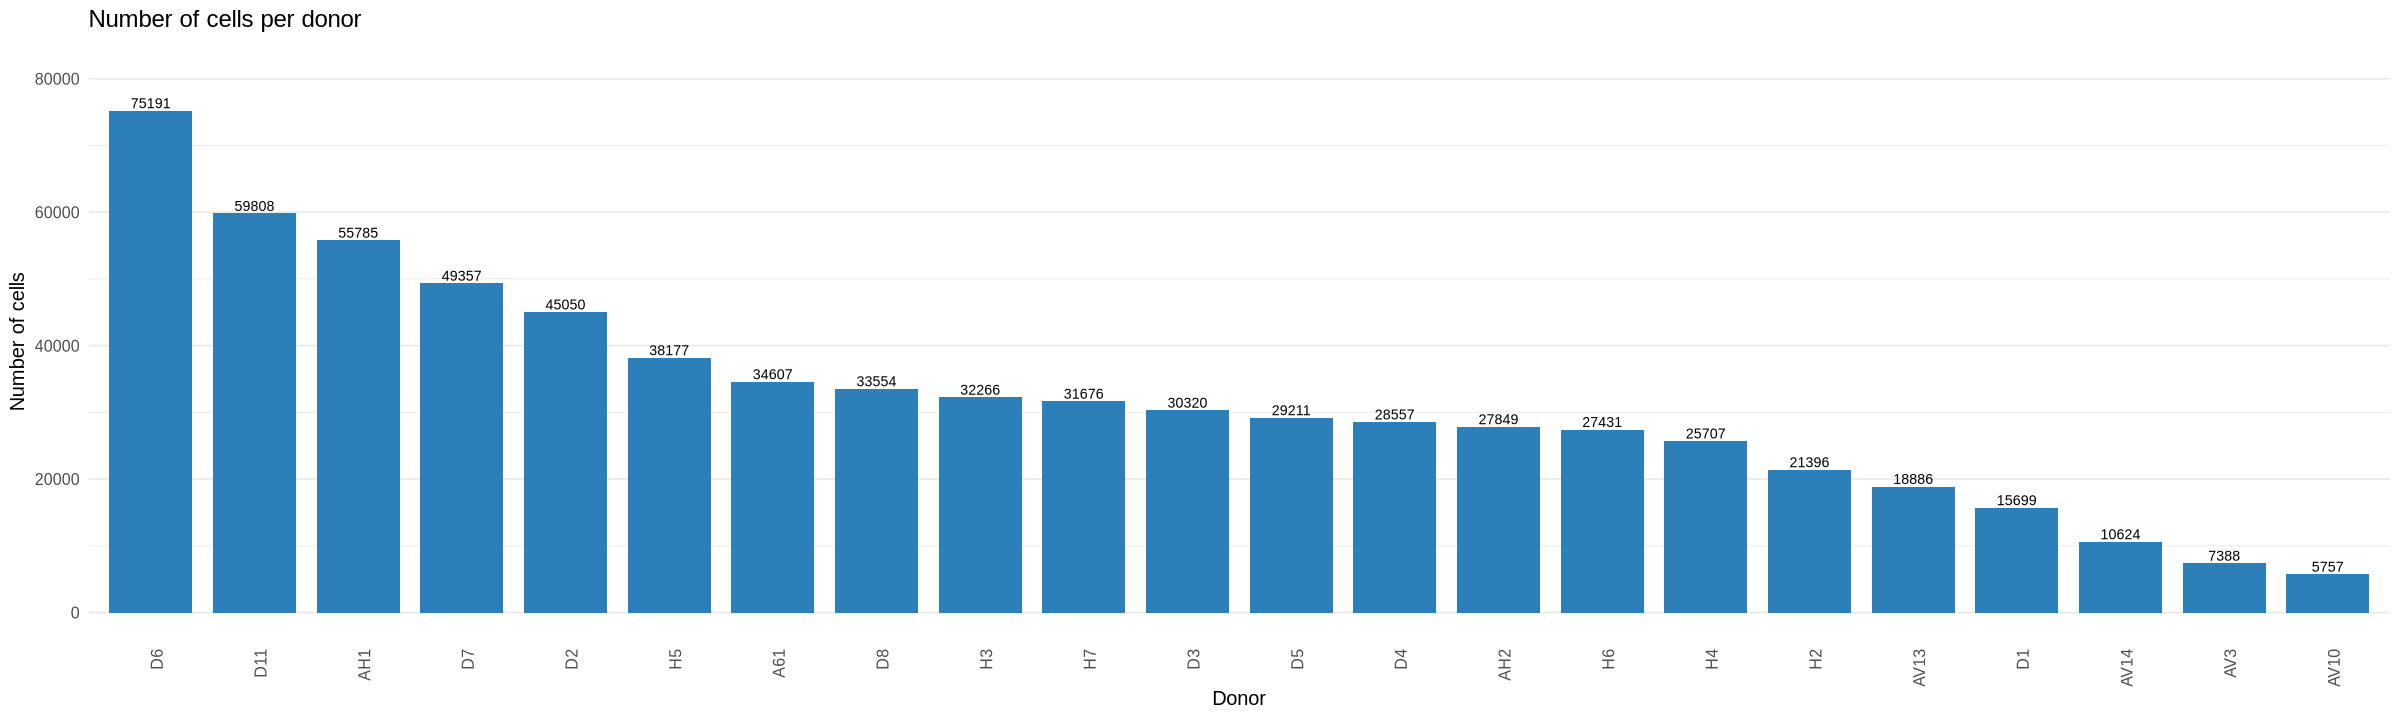

In [9]:
donor_counts <- as.data.frame(table(rna_obs[["donor"]]), stringsAsFactors = FALSE)
colnames(donor_counts) <- c("donor", "n_cells")
donor_counts <- donor_counts[order(donor_counts$n_cells, decreasing = TRUE), ]
donor_counts$donor <- factor(donor_counts$donor, levels = donor_counts$donor)

options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(donor_counts, aes(x = donor, y = n_cells)) +
    geom_col(fill = "#2C7FB8", width = 0.8) +
    geom_text(aes(label = n_cells), vjust = -0.25, size = 3) +
    labs(
        title = "Number of cells per donor",
        x = "Donor",
        y = "Number of cells"
    ) +
    theme_minimal(base_size = 12) +
    theme(
        axis.text.x = element_text(angle = 90, hjust = 1),
        panel.grid.major.x = element_blank()
    ) +
    expand_limits(y = max(donor_counts$n_cells) * 1.08)


In [13]:
head(rna_obs)

,sangerID,combinedID,donor,donor_type,region,region_finest,age,gender,facility,cell_or_nuclei,⋯,latent_scale,n_counts,_scvi_batch,_scvi_labels,clus20,doublet_cls,original_or_new,batch,scANVI_predictions,leiden_scArches
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
HCAHeart7606896_GATGAGGCACGGCTAC,HCAHeart7606896,na,D1,DBD,AX,AX,50-55,Female,Sanger,Cell,⋯,NA,NA,NA,NA,No,nan,original,D1_Cell_3prime-v2,Endothelial cell,10
HCAHeart7606896_CGCTTCACATTTGCCC,HCAHeart7606896,na,D1,DBD,AX,AX,50-55,Female,Sanger,Cell,⋯,NA,NA,NA,NA,No,nan,original,D1_Cell_3prime-v2,Mural cell,18
HCAHeart7606896_GTTAAGCAGAGACTAT,HCAHeart7606896,na,D1,DBD,AX,AX,50-55,Female,Sanger,Cell,⋯,NA,NA,NA,NA,No,nan,original,D1_Cell_3prime-v2,Endothelial cell,10
HCAHeart7606896_TCGCGTTGTAAGAGGA,HCAHeart7606896,na,D1,DBD,AX,AX,50-55,Female,Sanger,Cell,⋯,NA,NA,NA,NA,No,nan,original,D1_Cell_3prime-v2,Mural cell,3
HCAHeart7606896_GCTGCGAGTGTTGGGA,HCAHeart7606896,na,D1,DBD,AX,AX,50-55,Female,Sanger,Cell,⋯,NA,NA,NA,NA,No,nan,original,D1_Cell_3prime-v2,Endothelial cell,10
HCAHeart7606896_AAGACCTGTACTTGAC,HCAHeart7606896,na,D1,DBD,AX,AX,50-55,Female,Sanger,Cell,⋯,NA,NA,NA,NA,No,nan,original,D1_Cell_3prime-v2,Mural cell,18


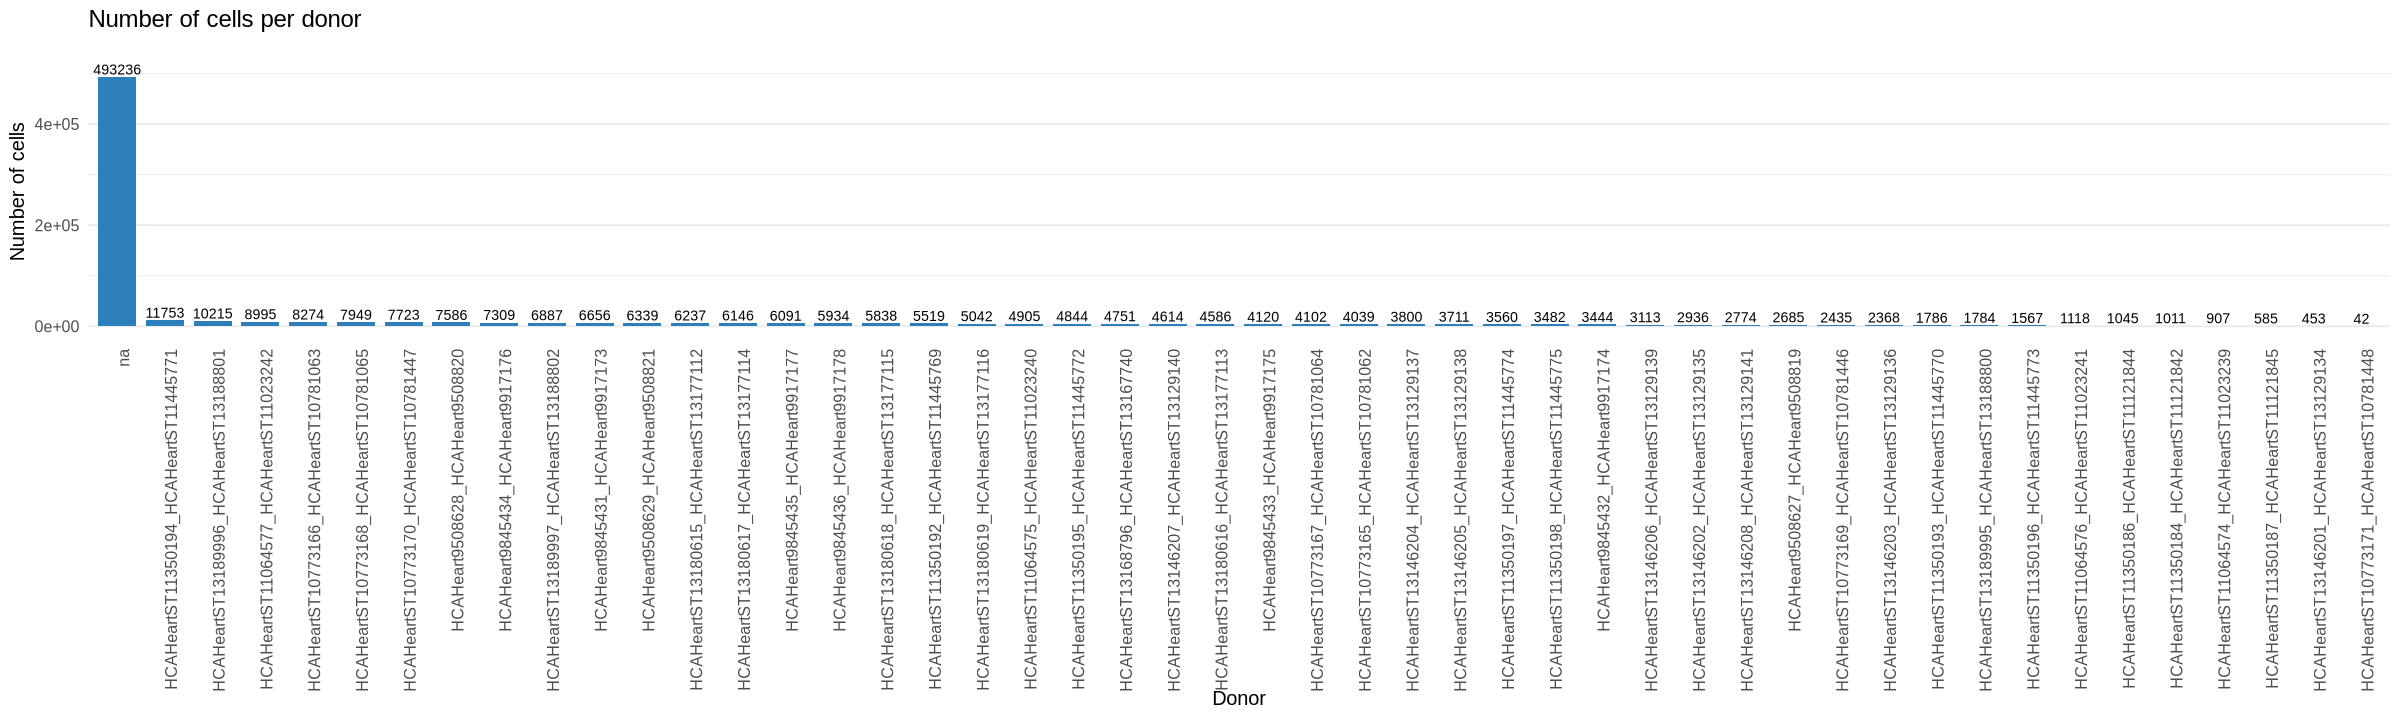

In [12]:

donor_counts <- as.data.frame(table(rna_obs[["combinedID"]]), stringsAsFactors = FALSE)
colnames(donor_counts) <- c("donor", "n_cells")
donor_counts <- donor_counts[order(donor_counts$n_cells, decreasing = TRUE), ]
donor_counts$donor <- factor(donor_counts$donor, levels = donor_counts$donor)

options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(donor_counts, aes(x = donor, y = n_cells)) +
    geom_col(fill = "#2C7FB8", width = 0.8) +
    geom_text(aes(label = n_cells), vjust = -0.25, size = 3) +
    labs(
        title = "Number of cells per donor",
        x = "Donor",
        y = "Number of cells"
    ) +
    theme_minimal(base_size = 12) +
    theme(
        axis.text.x = element_text(angle = 90, hjust = 1),
        panel.grid.major.x = element_blank()
    ) +
    expand_limits(y = max(donor_counts$n_cells) * 1.08)


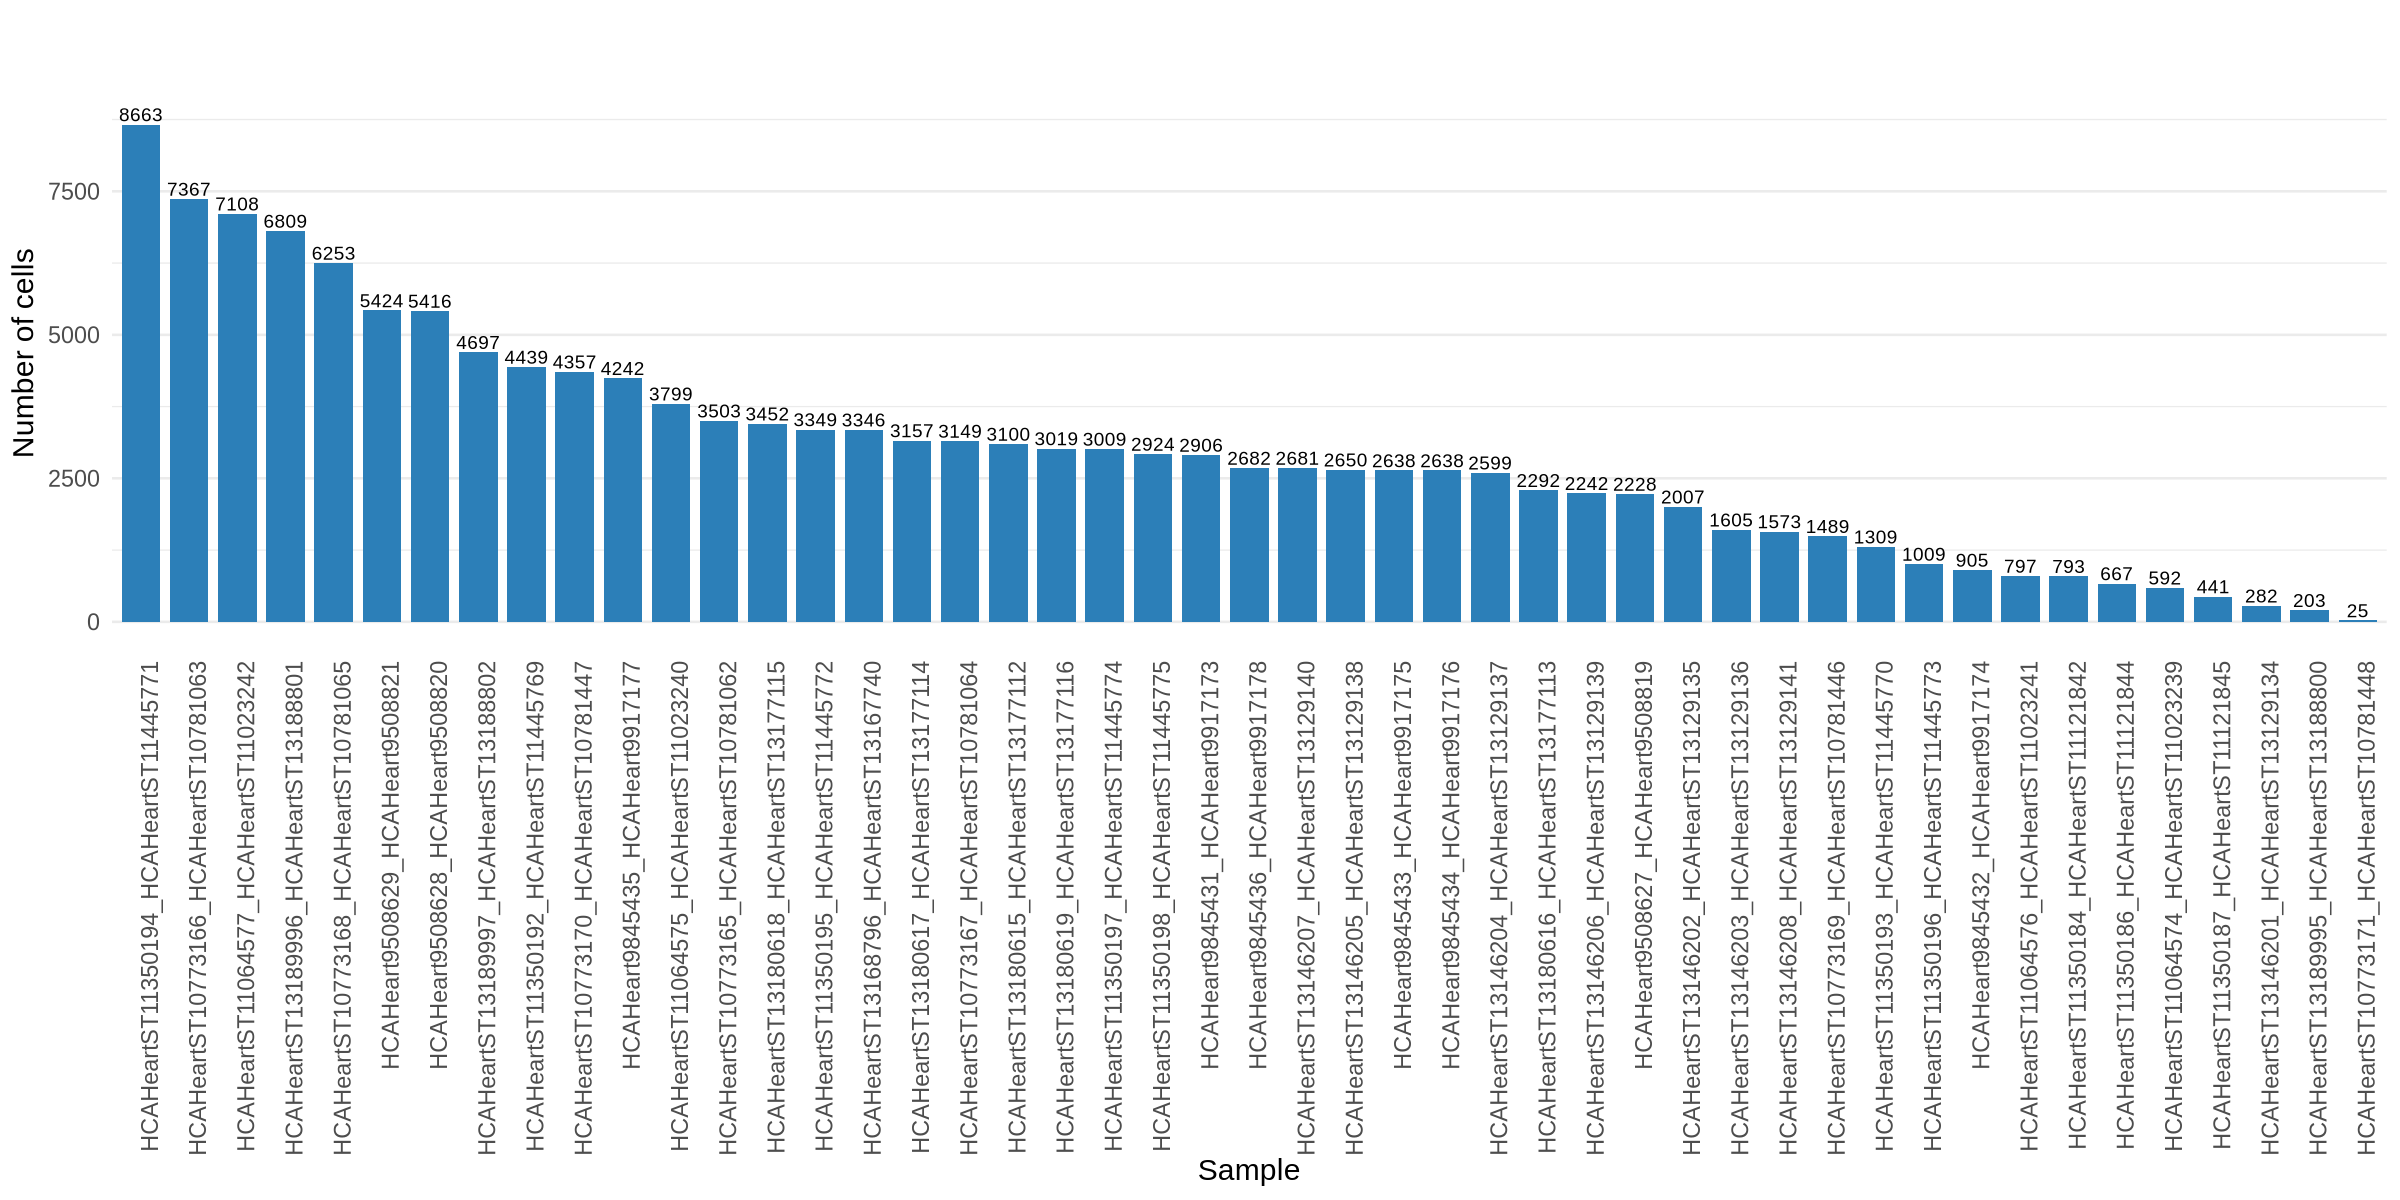

In [8]:
# number of cells per sample
cell_barcodes <- colnames(counts[["Gene Expression"]])

parts <- strsplit(cell_barcodes, "_", fixed = TRUE)
sample_prefixes <- vapply(
    parts,
    function(x) if (length(x) >= 2) paste(x[1:2], collapse = "_") else x[1],
    character(1)
)

sample_counts_df <- as.data.frame(table(sample_prefixes), stringsAsFactors = FALSE)
colnames(sample_counts_df) <- c("sample", "n_cells")
sample_counts_df <- sample_counts_df[order(sample_counts_df$n_cells, decreasing = TRUE), ]
sample_counts_df$sample <- factor(sample_counts_df$sample, levels = sample_counts_df$sample)

options(repr.plot.width = 20, repr.plot.height = 10)

ggplot(sample_counts_df, aes(x = sample, y = n_cells)) +
    geom_col(fill = "#2C7FB8", width = 0.8) +
    geom_text(aes(label = n_cells), vjust = -0.25, size = 4) +
    labs(
        title = "",
        x = "Sample",
        y = "Number of cells"
    ) +
    theme_minimal(base_size = 16) +
    theme(
        plot.title = element_text(size = 20, face = "bold"),
        axis.title.x = element_text(size = 18),
        axis.title.y = element_text(size = 18),
        axis.text.x = element_text(angle = 90, hjust = 1, size = 14),
        axis.text.y = element_text(size = 14),
        panel.grid.major.x = element_blank()
    ) +
    expand_limits(y = max(sample_counts_df$n_cells) * 1.08)


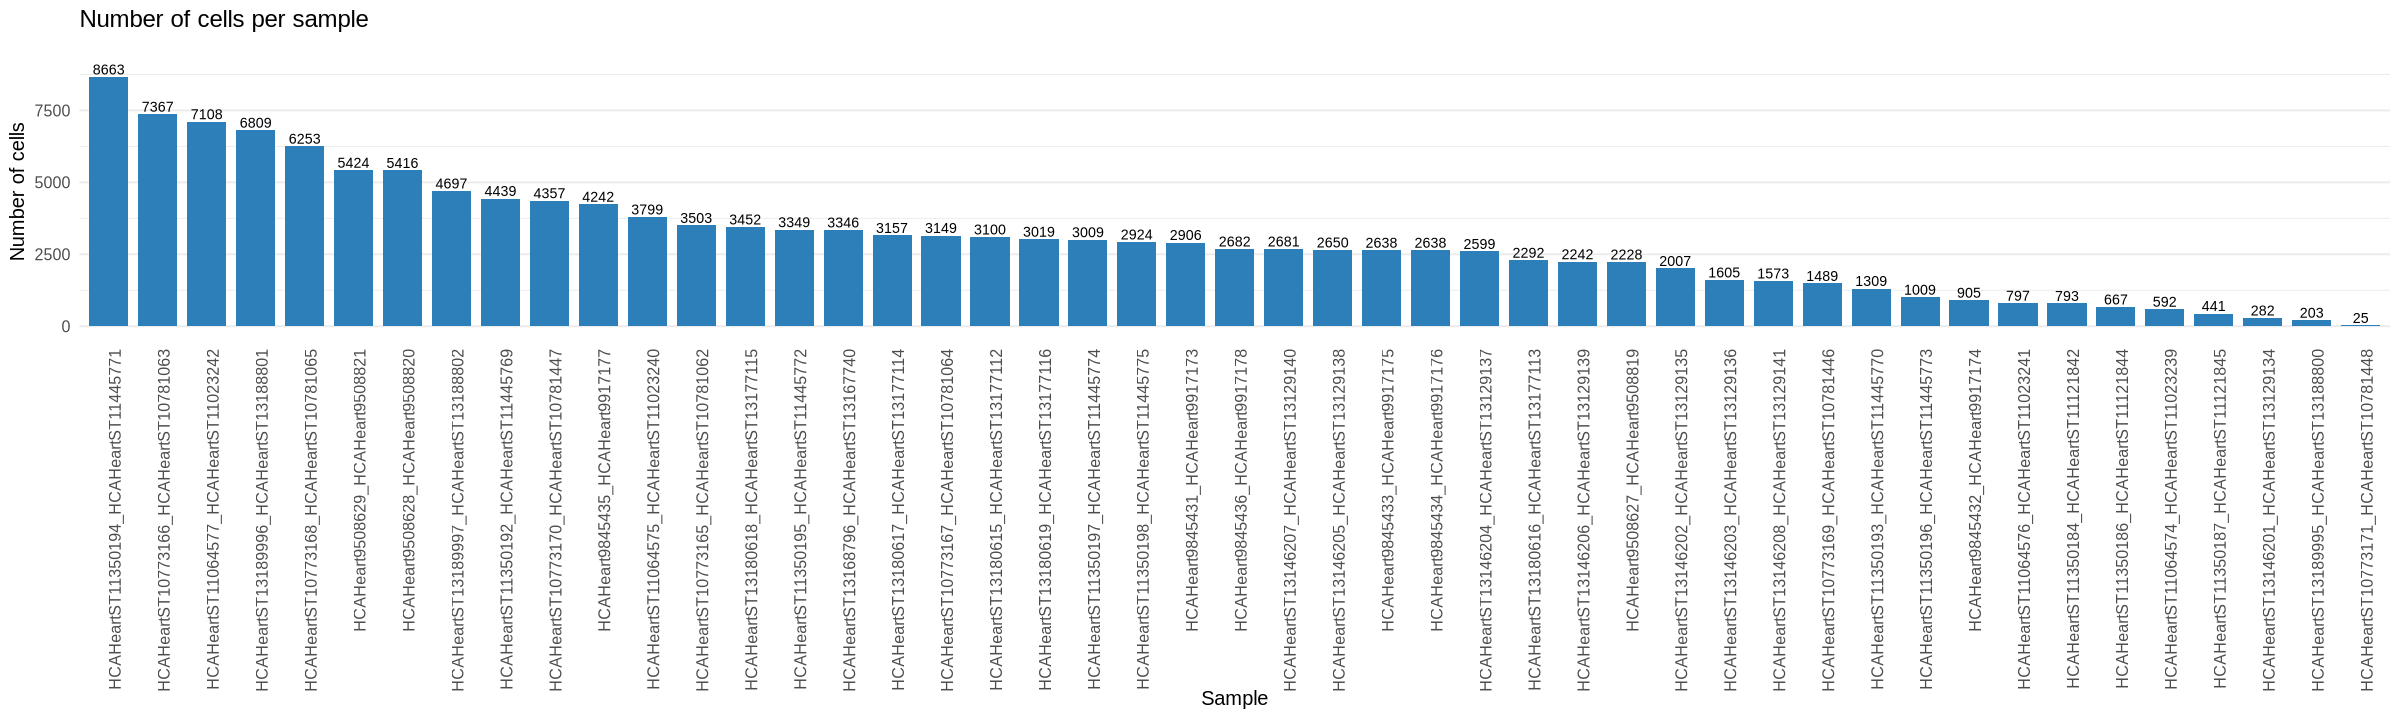

In [32]:
library(ggplot2)

# number of cells per sample
cell_barcodes <- colnames(counts[["Gene Expression"]])

parts <- strsplit(cell_barcodes, "_", fixed = TRUE)
sample_prefixes <- vapply(
    parts,
    function(x) if (length(x) >= 2) paste(x[1:2], collapse = "_") else x[1],
    character(1)
)

sample_counts_df <- as.data.frame(table(sample_prefixes), stringsAsFactors = FALSE)
colnames(sample_counts_df) <- c("sample", "n_cells")
sample_counts_df <- sample_counts_df[order(sample_counts_df$n_cells, decreasing = TRUE), ]
sample_counts_df$sample <- factor(sample_counts_df$sample, levels = sample_counts_df$sample)
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(sample_counts_df, aes(x = sample, y = n_cells)) +
    geom_col(fill = "#2C7FB8", width = 0.8) +
    geom_text(aes(label = n_cells), vjust = -0.25, size = 3) +
    labs(
        title = "Number of cells per sample",
        x = "Sample",
        y = "Number of cells"
    ) +
    theme_minimal(base_size = 12) +
    theme(
        axis.text.x = element_text(angle = 90, hjust = 1),
        panel.grid.major.x = element_blank()
    ) +
    expand_limits(y = max(sample_counts_df$n_cells) * 1.08)



In [34]:
head(sample_counts_df)

,sample,n_cells
,<fct>,<int>
26,HCAHeartST11350194_HCAHeartST11445771,8663
11,HCAHeartST10773166_HCAHeartST10781063,7367
20,HCAHeartST11064577_HCAHeartST11023242,7108
46,HCAHeartST13189996_HCAHeartST13188801,6809
13,HCAHeartST10773168_HCAHeartST10781065,6253
3,HCAHeart9508629_HCAHeart9508821,5424


In [38]:
sample_to_use <- sample_counts_df[1,"sample"]

In [64]:
paste0("/nfs/data3/mopitas/mapra/cell_atlas_data/", sample_to_use, "_atac_fragments.tsv.gz")

[1] "/nfs/data3/mopitas/mapra/cell_atlas_data/HCAHeartST11350194_HCAHeartST11445771_atac_fragments.tsv.gz"

In [41]:
fragpath <- paste0("/nfs/data3/mopitas/mapra/cell_atlas_data/", sample_to_use, "_atac_fragments.tsv.gz")

stopifnot(file.exists(fragpath))

In [65]:
# subset counts to one sample for both assays
cells_keep <- startsWith(colnames(counts[["Gene Expression"]]), paste0(sample_to_use, "_"))

counts_sample <- list(
    "Gene Expression" = counts[["Gene Expression"]][, cells_keep, drop = FALSE],
    "Peaks" = counts[["Peaks"]][, cells_keep, drop = FALSE]
)

# rename cell barcodes to match fragment file format
old_cells <- colnames(counts_sample[["Gene Expression"]])
new_cells <- sub(paste0("^", sample_to_use, "_"), "", old_cells)

if (anyDuplicated(new_cells)) {
  stop("Duplicate cell barcodes after prefix removal.")
}
if (!all(nzchar(new_cells))) {
  stop("Empty cell barcode generated after prefix removal.")
}

colnames(counts_sample[["Gene Expression"]]) <- new_cells
colnames(counts_sample[["Peaks"]]) <- new_cells

stopifnot(identical(
  colnames(counts_sample[["Gene Expression"]]),
  colnames(counts_sample[["Peaks"]])
))

head(colnames(counts_sample[["Gene Expression"]]))

[1] "ACCACATAGGGCTAAA-1" "ACATTAGTCCTAGTAA-1" "TCGGTTCTCGGGACCT-1"
[4] "AGACTATGTAACCAGC-1" "ATTATCCTCGCACACA-1" "CGCACACAGGTTACAC-1"

In [67]:
# normalize peak feature names to Signac format: chr:start-end
peak_names <- rownames(counts_sample[["Peaks"]])
peak_names <- gsub("_", "-", peak_names, fixed = TRUE)

valid_peak_pattern <- "^[^:]+:[0-9]+-[0-9]+$"
if (any(!grepl(valid_peak_pattern, peak_names))) {
  bad_examples <- head(peak_names[!grepl(valid_peak_pattern, peak_names)], 5)
  stop(
    "Invalid peak names after normalization. Examples: ",
    paste(bad_examples, collapse = ", ")
  )
}
rownames(counts_sample[["Peaks"]]) <- peak_names

head(counts_sample[["Peaks"]])


  [[ suppressing 8663 column names 'ACCACATAGGGCTAAA-1', 'ACATTAGTCCTAGTAA-1', 'TCGGTTCTCGGGACCT-1' ... ]]



6 x 8663 sparse Matrix of class "dgCMatrix"
                                                                              
chr1:794932-795432 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1:817104-817604 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1:818775-819275 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1:819697-820197 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1:821364-821864 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1:825517-826017 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
                                                                              
chr1:794932-795432 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr1:817104-817604 . . . . . . . . . . . . . . . . . 2 . . . . 1 . . . . . . .
chr1:818775-819275 . . . . . . . . . . . . . . 2 . . . . . . . . . . . . . . .
chr1:819697-820197 . . . . . . . . . . . . . . . . . . 2 . . . . . . . . . . .
chr1:821

In [81]:
harmonize_obs_for_sample <- function(obs_df, sample_name, target_cells, label) {
  sample_rows <- startsWith(rownames(obs_df), paste0(sample_name, "_"))
  out <- obs_df[sample_rows, , drop = FALSE]
  rownames(out) <- sub(paste0("^", sample_name, "_"), "", rownames(out))

  if (anyDuplicated(rownames(out))) {
    stop("Duplicate barcodes in ", label, " after prefix removal.")
  }

  missing_cells <- setdiff(target_cells, rownames(out))
  if (length(missing_cells) > 0) {
    stop(
      "Missing ", label, " metadata for cells (examples): ",
      paste(head(missing_cells, 5), collapse = ", ")
    )
  }

  out[target_cells, , drop = FALSE]
}

In [82]:
# get gene annotations for hg38
annotation <- GetGRangesFromEnsDb(ensdb = EnsDb.Hsapiens.v86)
seqlevels(annotation) <- paste0("chr", seqlevels(annotation))

# create a Seurat object containing RNA counts
heart_cell_atlas <- CreateSeuratObject(
  counts = counts_sample[["Gene Expression"]],
  assay = "RNA"
 )


cells <- colnames(heart_cell_atlas)
rna_obs_sample <- harmonize_obs_for_sample(rna_obs, sample_to_use, cells, "rna_obs")
peak_obs_sample <- harmonize_obs_for_sample(peak_obs, sample_to_use, cells, "peak_obs")

# avoid metadata name collisions
colnames(peak_obs_sample) <- paste0("peak_", colnames(peak_obs_sample))

heart_cell_atlas <- AddMetaData(heart_cell_atlas, metadata = rna_obs_sample)
heart_cell_atlas <- AddMetaData(heart_cell_atlas, metadata = peak_obs_sample)

# create Peaks assay and add it to the object
heart_cell_atlas[["Peaks"]] <- CreateChromatinAssay(
  counts = counts_sample[["Peaks"]],
  sep = c(":", "-"),
  fragments = fragpath,
  annotation = annotation
)

heart_cell_atlas

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warn

An object of class Seurat 
462560 features across 8663 samples within 2 assays 
Active assay: RNA (32732 features, 0 variable features)
 1 layer present: counts
 1 other assay present: Peaks

In [89]:

saveRDS(heart_cell_atlas, file.path(out_dir, paste0(sample_to_use, ".rds")))